# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** [Daniel Alfarezi]
- **Email:** [2212500272@student.budiluhur.ac.id]
- **ID Dicoding:** [daniel_alfarezi_ktJp]

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pola penggunaan sepeda berdasarkan musim dan kondisi cuaca? Musim dan cuaca mana yang paling banyak dan paling sedikit digunakan?
- **Pertanyaan 2:** Bagaimana perbandingan pola penggunaan sepeda antara hari kerja dan hari libur berdasarkan jam dalam sehari? Jam berapa puncak penggunaan pada masing-masing kategori hari?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Konfigurasi visualisasiS
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Data Wrangling

### Gathering Data

Dataset ini terdiri dari dua file CSV:
- `day.csv`: Data harian penyewaan sepeda (731 baris)
- `hour.csv`: Data per jam penyewaan sepeda (17379 baris)

Berikut penjelasan kolom pada dataset:
- `instant`: Index record
- `dteday`: Tanggal
- `season`: Musim (1: Spring, 2: Summer, 3: Fall, 4: Winter)
- `yr`: Tahun (0: 2011, 1: 2012)
- `mnth`: Bulan (1-12)
- `hr`: Jam (0-23, hanya di hour.csv)
- `holiday`: Hari libur (1) atau bukan (0)
- `weekday`: Hari dalam seminggu (0-6)
- `workingday`: Hari kerja (1) atau bukan (0)
- `weathersit`: Kondisi cuaca (1: Cerah, 2: Berawan, 3: Hujan ringan, 4: Hujan lebat)
- `temp`: Temperatur normal (0-1)
- `atemp`: Temperatur yang dirasakan normal (0-1)
- `hum`: Kelembapan normal (0-1)
- `windspeed`: Kecepatan angin normal (0-1)
- `casual`: Pengguna kasual (tidak terdaftar)
- `registered`: Pengguna terdaftar
- `cnt`: Total penyewaan sepeda (casual + registered)

In [2]:
# Membaca dataset
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print("=== Dataset Harian (day.csv) ===")
print(f"Jumlah baris: {day_df.shape[0]}, Jumlah kolom: {day_df.shape[1]}")
print()
day_df.head()

=== Dataset Harian (day.csv) ===
Jumlah baris: 731, Jumlah kolom: 16



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
print("=== Dataset Per Jam (hour.csv) ===")
print(f"Jumlah baris: {hour_df.shape[0]}, Jumlah kolom: {hour_df.shape[1]}")
print()
hour_df.head()

=== Dataset Per Jam (hour.csv) ===
Jumlah baris: 17379, Jumlah kolom: 17



,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset harian memiliki 731 baris data yang mencakup 2 tahun (2011-2012).
- Dataset per jam memiliki 17.379 baris data dengan tambahan kolom `hr` (jam).
- Semua fitur numerik telah dinormalisasi ke rentang 0-1.

### Assessing Data

In [4]:
# Memeriksa informasi dataset harian
print("=== Info Dataset Harian ===")
day_df.info()
print()
print("=== Statistik Deskriptif Dataset Harian ===")
day_df.describe()

=== Info Dataset Harian ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

=== Statistik Deskriptif Dataset Harian ===


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [5]:
# Memeriksa informasi dataset per jam
print("=== Info Dataset Per Jam ===")
hour_df.info()
print()
print("=== Statistik Deskriptif Dataset Per Jam ===")
hour_df.describe()

=== Info Dataset Per Jam ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

=== Statistik Deskr

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [6]:
# Memeriksa missing values
print("=== Missing Values Dataset Harian ===")
print(day_df.isnull().sum())
print()
print("=== Missing Values Dataset Per Jam ===")
print(hour_df.isnull().sum())

=== Missing Values Dataset Harian ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Values Dataset Per Jam ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [7]:
# Memeriksa duplikat
print(f"Jumlah duplikat dataset harian: {day_df.duplicated().sum()}")
print(f"Jumlah duplikat dataset per jam: {hour_df.duplicated().sum()}")

Jumlah duplikat dataset harian: 0
Jumlah duplikat dataset per jam: 0


In [8]:
# Memeriksa tipe data
print("=== Tipe Data Dataset Harian ===")
print(day_df.dtypes)
print()
print("=== Tipe Data Dataset Per Jam ===")
print(hour_df.dtypes)

=== Tipe Data Dataset Harian ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Tipe Data Dataset Per Jam ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Insight:**
- Tidak ada missing values pada kedua dataset.
- Tidak ada data duplikat.
- Kolom `dteday` bertipe `object`, perlu diubah menjadi `datetime`.
- Kolom kategorikal seperti `season`, `weathersit`, `weekday` masih berformat numerik, perlu di-mapping ke label yang bermakna.
- Kolom `yr` bernilai 0 dan 1 yang merepresentasikan tahun 2011 dan 2012.

### Cleaning Data

In [9]:
# Konversi tipe data dteday
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping kolom season
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_label'] = day_df['season'].map(season_map)
hour_df['season_label'] = hour_df['season'].map(season_map)

# Mapping kolom weathersit
weather_map = {1: 'Cerah', 2: 'Berawan', 3: 'Hujan Ringan', 4: 'Hujan Lebat'}
day_df['weather_label'] = day_df['weathersit'].map(weather_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)

# Mapping kolom yr
year_map = {0: 2011, 1: 2012}
day_df['year'] = day_df['yr'].map(year_map)
hour_df['year'] = hour_df['yr'].map(year_map)

# Mapping kolom weekday
weekday_map = {0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}
day_df['weekday_label'] = day_df['weekday'].map(weekday_map)
hour_df['weekday_label'] = hour_df['weekday'].map(weekday_map)

# Mapping kolom mnth
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
             7: 'Jul', 8: 'Ags', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'}
day_df['month_label'] = day_df['mnth'].map(month_map)
hour_df['month_label'] = hour_df['mnth'].map(month_map)

# Membuat kolom tipe hari
day_df['day_type'] = day_df['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})
hour_df['day_type'] = hour_df['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})

# Denormalisasi temperatur untuk kemudahan interpretasi
# temp: normalized temp in Celsius (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39
day_df['temp_actual'] = day_df['temp'] * 47 - 8
hour_df['temp_actual'] = hour_df['temp'] * 47 - 8

print("Data cleaning selesai!")
print()
day_df.head()

Data cleaning selesai!



,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,casual,registered,cnt,season_label,weather_label,year,weekday_label,month_label,day_type,temp_actual
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,331,654,985,Spring,Berawan,2011,Sabtu,Jan,Hari Libur/Weekend,8.175849
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,131,670,801,Spring,Berawan,2011,Minggu,Jan,Hari Libur/Weekend,9.083466
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,120,1229,1349,Spring,Cerah,2011,Senin,Jan,Hari Kerja,1.229108
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,108,1454,1562,Spring,Cerah,2011,Selasa,Jan,Hari Kerja,1.400000
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,82,1518,1600,Spring,Cerah,2011,Rabu,Jan,Hari Kerja,2.666979


In [10]:
# Verifikasi hasil cleaning
print("=== Tipe Data Setelah Cleaning (day_df) ===")
print(day_df.dtypes)
print()
print("=== Unique Values Kolom Kategorikal ===")
print(f"Season: {day_df['season_label'].unique()}")
print(f"Weather: {day_df['weather_label'].unique()}")
print(f"Year: {day_df['year'].unique()}")
print(f"Weekday: {day_df['weekday_label'].unique()}")

=== Tipe Data Setelah Cleaning (day_df) ===
instant                   int64
dteday           datetime64[ns]
season                    int64
yr                        int64
mnth                      int64
holiday                   int64
weekday                   int64
workingday                int64
weathersit                int64
temp                    float64
atemp                   float64
hum                     float64
windspeed               float64
casual                    int64
registered                int64
cnt                       int64
season_label             object
weather_label            object
year                      int64
weekday_label            object
month_label              object
day_type                 object
temp_actual             float64
dtype: object

=== Unique Values Kolom Kategorikal ===
Season: ['Spring' 'Summer' 'Fall' 'Winter']
Weather: ['Berawan' 'Cerah' 'Hujan Ringan']
Year: [2011 2012]
Weekday: ['Sabtu' 'Minggu' 'Senin' 'Selasa' 'Rabu' 'Kamis' 

**Insight:**
- Kolom `dteday` berhasil dikonversi menjadi tipe `datetime64`.
- Kolom-kolom kategorikal telah di-mapping ke label yang lebih bermakna.
- Temperatur telah di-denormalisasi ke satuan Celsius untuk memudahkan interpretasi.
- Ditambahkan kolom `day_type` untuk membedakan hari kerja dan hari libur/weekend.

## Exploratory Data Analysis (EDA)

### Explore Distribusi dan Tren Penyewaan Sepeda

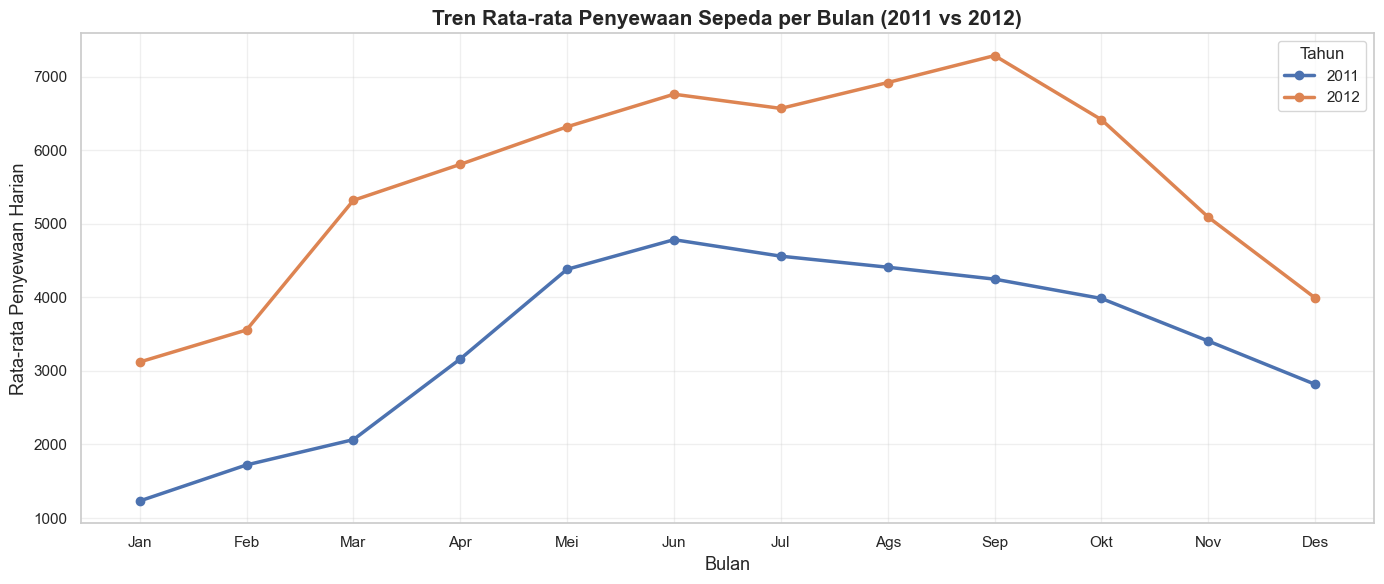

In [11]:
# Tren penyewaan sepeda per bulan (2011 vs 2012)
monthly_trend = day_df.groupby(['year', 'mnth'])['cnt'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for year in [2011, 2012]:
    data = monthly_trend[monthly_trend['year'] == year]
    ax.plot(data['mnth'], data['cnt'], marker='o', linewidth=2.5, label=str(year))

ax.set_xlabel('Bulan', fontsize=13)
ax.set_ylabel('Rata-rata Penyewaan Harian', fontsize=13)
ax.set_title('Tren Rata-rata Penyewaan Sepeda per Bulan (2011 vs 2012)', fontsize=15, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des'])
ax.legend(title='Tahun', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

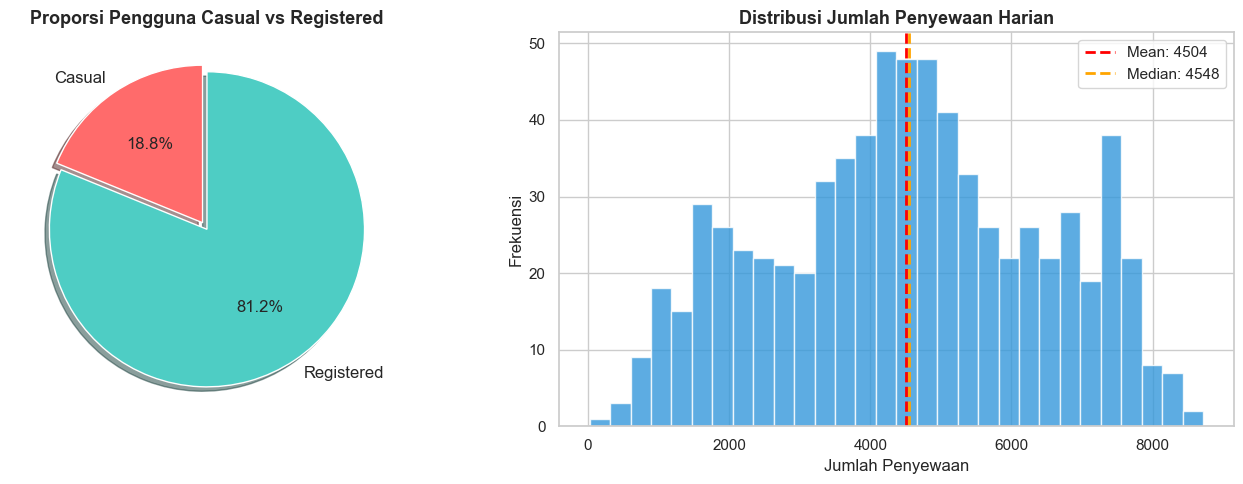

In [12]:
# Distribusi penyewaan berdasarkan pengguna casual vs registered
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Proporsi keseluruhan
total_casual = day_df['casual'].sum()
total_registered = day_df['registered'].sum()
labels = ['Casual', 'Registered']
sizes = [total_casual, total_registered]
colors = ['#FF6B6B', '#4ECDC4']
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Proporsi Pengguna Casual vs Registered', fontsize=13, fontweight='bold')

# Distribusi cnt
axes[1].hist(day_df['cnt'], bins=30, color='#3498DB', edgecolor='white', alpha=0.8)
axes[1].axvline(day_df['cnt'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {day_df["cnt"].mean():.0f}')
axes[1].axvline(day_df['cnt'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {day_df["cnt"].median():.0f}')
axes[1].set_xlabel('Jumlah Penyewaan', fontsize=12)
axes[1].set_ylabel('Frekuensi', fontsize=12)
axes[1].set_title('Distribusi Jumlah Penyewaan Harian', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

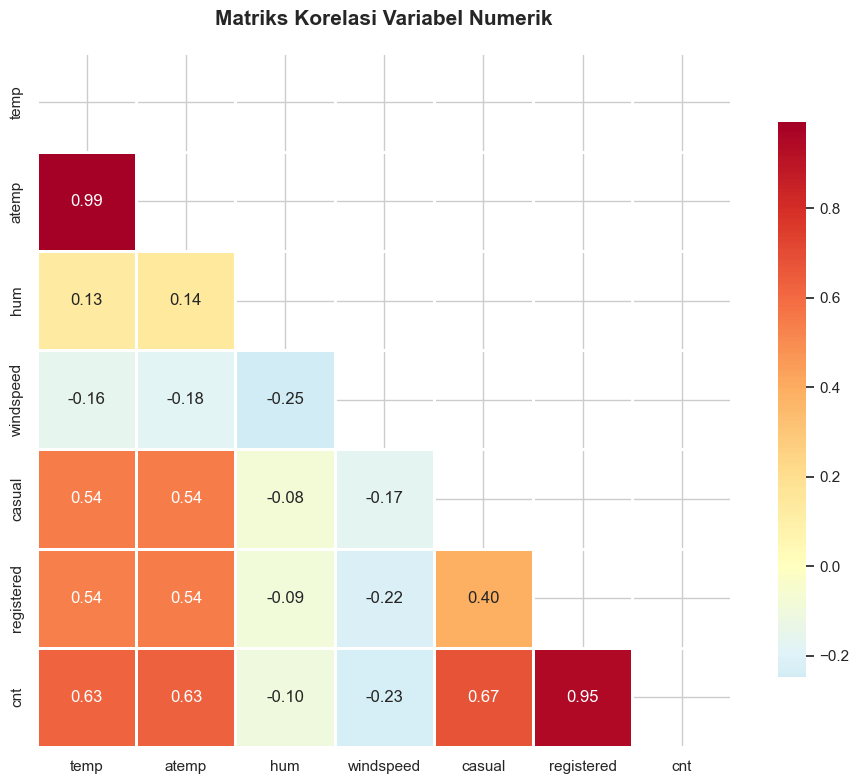

In [13]:
# Korelasi antar variabel numerik
correlation_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = day_df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriks Korelasi Variabel Numerik', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Insight:**
- Terdapat tren peningkatan penyewaan dari 2011 ke 2012, menunjukkan pertumbuhan popularitas layanan.
- Puncak penyewaan terjadi pada bulan Juni-September (musim panas/gugur) dan terendah di bulan Januari.
- Pengguna registered mendominasi (sekitar 81%) dibanding casual (sekitar 19%).
- Temperatur memiliki korelasi positif kuat dengan jumlah penyewaan (r ≈ 0.63), sementara kelembapan dan kecepatan angin berkorelasi negatif.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola penggunaan sepeda berdasarkan musim dan kondisi cuaca?

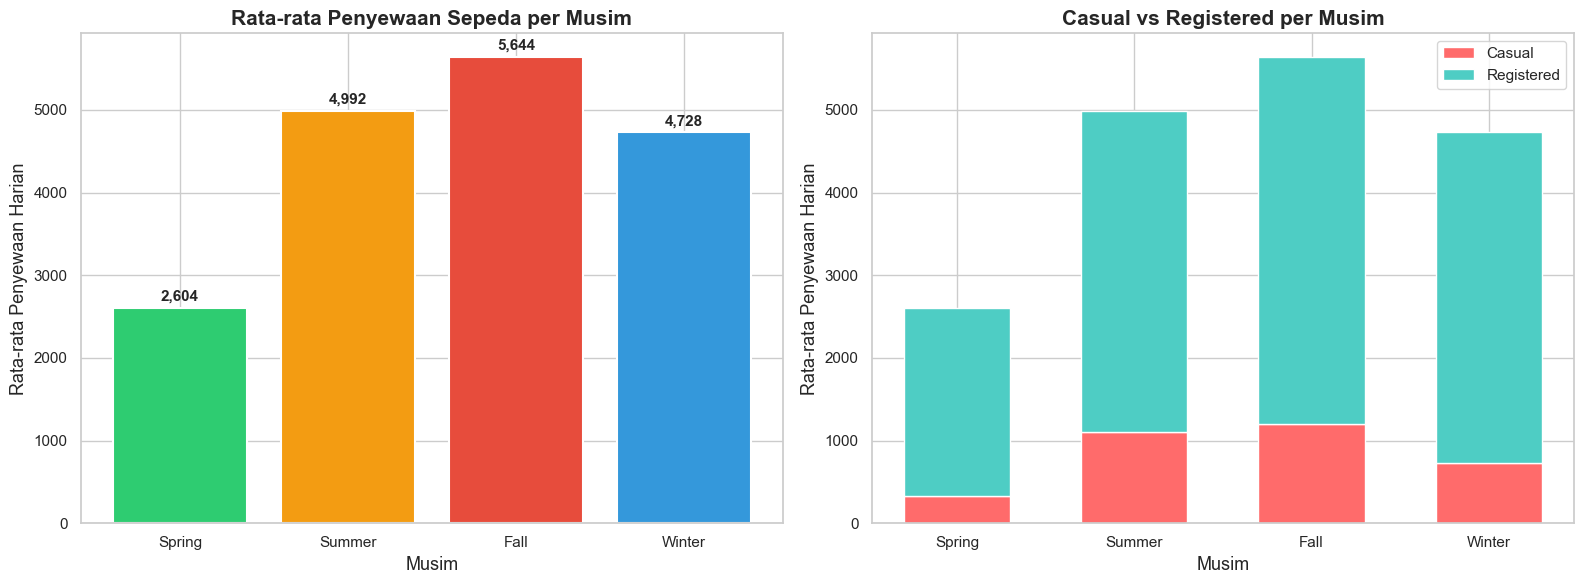


Statistik Penyewaan per Musim:
season_label  total_cnt     avg_cnt  avg_casual  avg_registered
      Spring     471348 2604.132597  334.928177     2269.204420
      Summer     918589 4992.331522 1106.097826     3886.233696
        Fall    1061129 5644.303191 1202.611702     4441.691489
      Winter     841613 4728.162921  729.112360     3999.050562


In [14]:
# Analisis berdasarkan musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_stats = day_df.groupby('season_label').agg(
    total_cnt=('cnt', 'sum'),
    avg_cnt=('cnt', 'mean'),
    avg_casual=('casual', 'mean'),
    avg_registered=('registered', 'mean')
).reindex(season_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart rata-rata penyewaan per musim
colors_season = ['#2ECC71', '#F39C12', '#E74C3C', '#3498DB']
bars = axes[0].bar(season_stats['season_label'], season_stats['avg_cnt'], color=colors_season, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Musim', fontsize=13)
axes[0].set_ylabel('Rata-rata Penyewaan Harian', fontsize=13)
axes[0].set_title('Rata-rata Penyewaan Sepeda per Musim', fontsize=15, fontweight='bold')

# Tambahkan label nilai di atas bar
for bar, val in zip(bars, season_stats['avg_cnt']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Stacked bar: casual vs registered per musim
x = np.arange(len(season_order))
width = 0.6
axes[1].bar(x, season_stats['avg_casual'], width, label='Casual', color='#FF6B6B')
axes[1].bar(x, season_stats['avg_registered'], width, bottom=season_stats['avg_casual'], label='Registered', color='#4ECDC4')
axes[1].set_xlabel('Musim', fontsize=13)
axes[1].set_ylabel('Rata-rata Penyewaan Harian', fontsize=13)
axes[1].set_title('Casual vs Registered per Musim', fontsize=15, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(season_order)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\nStatistik Penyewaan per Musim:")
print(season_stats.to_string(index=False))

C:\Users\salty\AppData\Local\Temp\ipykernel_22940\2436365803.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(weather_data, labels=weather_stats['weather_label'].tolist(),


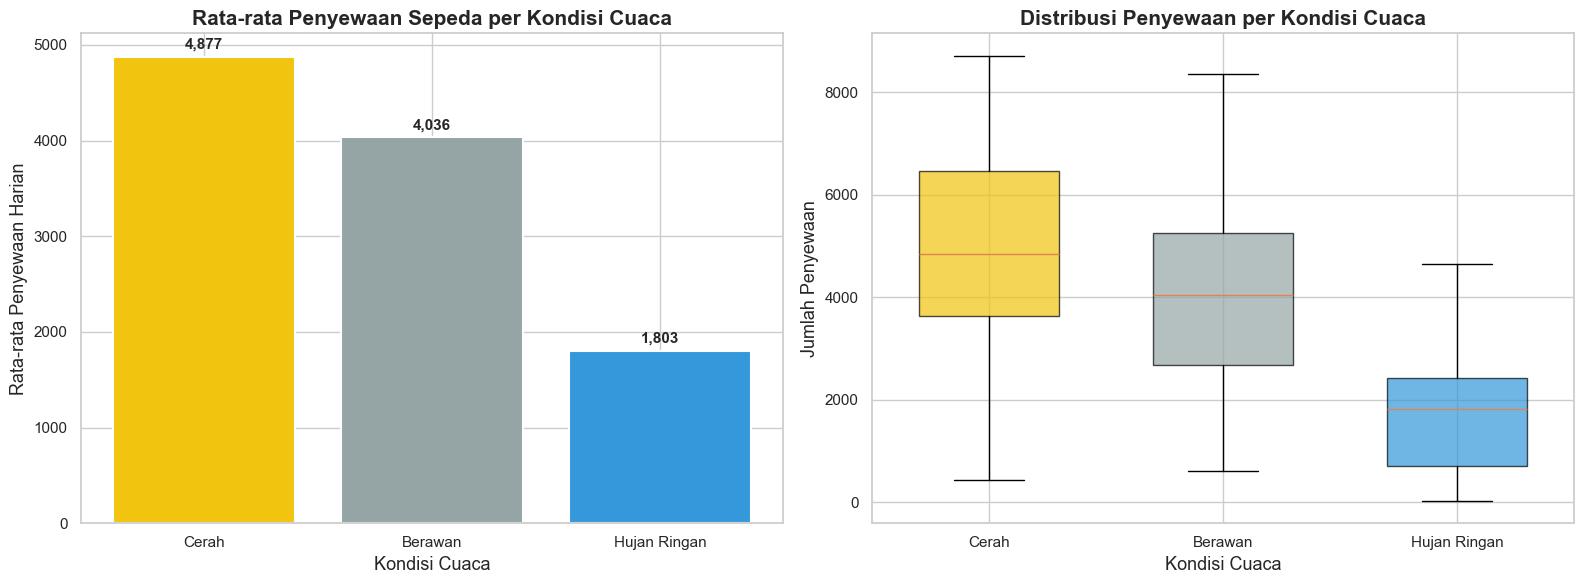


Statistik Penyewaan per Kondisi Cuaca:
weather_label  total_cnt     avg_cnt  count_days
        Cerah    2257952 4876.786177         463
      Berawan     996858 4035.862348         247
 Hujan Ringan      37869 1803.285714          21


In [15]:
# Analisis berdasarkan kondisi cuaca
weather_order = ['Cerah', 'Berawan', 'Hujan Ringan', 'Hujan Lebat']
weather_stats = day_df.groupby('weather_label').agg(
    total_cnt=('cnt', 'sum'),
    avg_cnt=('cnt', 'mean'),
    count_days=('cnt', 'count')
).reindex([w for w in weather_order if w in day_df['weather_label'].unique()]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart rata-rata penyewaan per cuaca
colors_weather = ['#F1C40F', '#95A5A6', '#3498DB', '#2C3E50']
available_colors = colors_weather[:len(weather_stats)]
bars = axes[0].bar(weather_stats['weather_label'], weather_stats['avg_cnt'],
                   color=available_colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Kondisi Cuaca', fontsize=13)
axes[0].set_ylabel('Rata-rata Penyewaan Harian', fontsize=13)
axes[0].set_title('Rata-rata Penyewaan Sepeda per Kondisi Cuaca', fontsize=15, fontweight='bold')

for bar, val in zip(bars, weather_stats['avg_cnt']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Boxplot distribusi penyewaan per cuaca
weather_data = [day_df[day_df['weather_label'] == w]['cnt'] for w in weather_stats['weather_label']]
bp = axes[1].boxplot(weather_data, labels=weather_stats['weather_label'].tolist(),
                     patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], available_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Kondisi Cuaca', fontsize=13)
axes[1].set_ylabel('Jumlah Penyewaan', fontsize=13)
axes[1].set_title('Distribusi Penyewaan per Kondisi Cuaca', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nStatistik Penyewaan per Kondisi Cuaca:")
print(weather_stats.to_string(index=False))

**Insight Pertanyaan 1:**
- **Musim Fall (Gugur)** memiliki rata-rata penyewaan tertinggi, diikuti oleh Summer (Panas) dan Winter (Dingin).
- **Musim Spring (Semi)** memiliki rata-rata penyewaan terendah.
- Pengguna registered mendominasi di semua musim, namun proporsi pengguna casual meningkat signifikan di musim Summer dan Fall.
- **Cuaca cerah** menghasilkan penyewaan tertinggi, sementara **hujan ringan** menurunkan penyewaan secara drastis.
- Kondisi cuaca hujan lebat hampir tidak pernah terjadi dalam dataset (sangat jarang), sehingga datanya sangat sedikit.
- Terdapat variasi yang lebih besar pada penyewaan di cuaca cerah dibanding cuaca berawan.

### Pertanyaan 2: Bagaimana perbandingan pola penggunaan sepeda antara hari kerja dan hari libur berdasarkan jam?

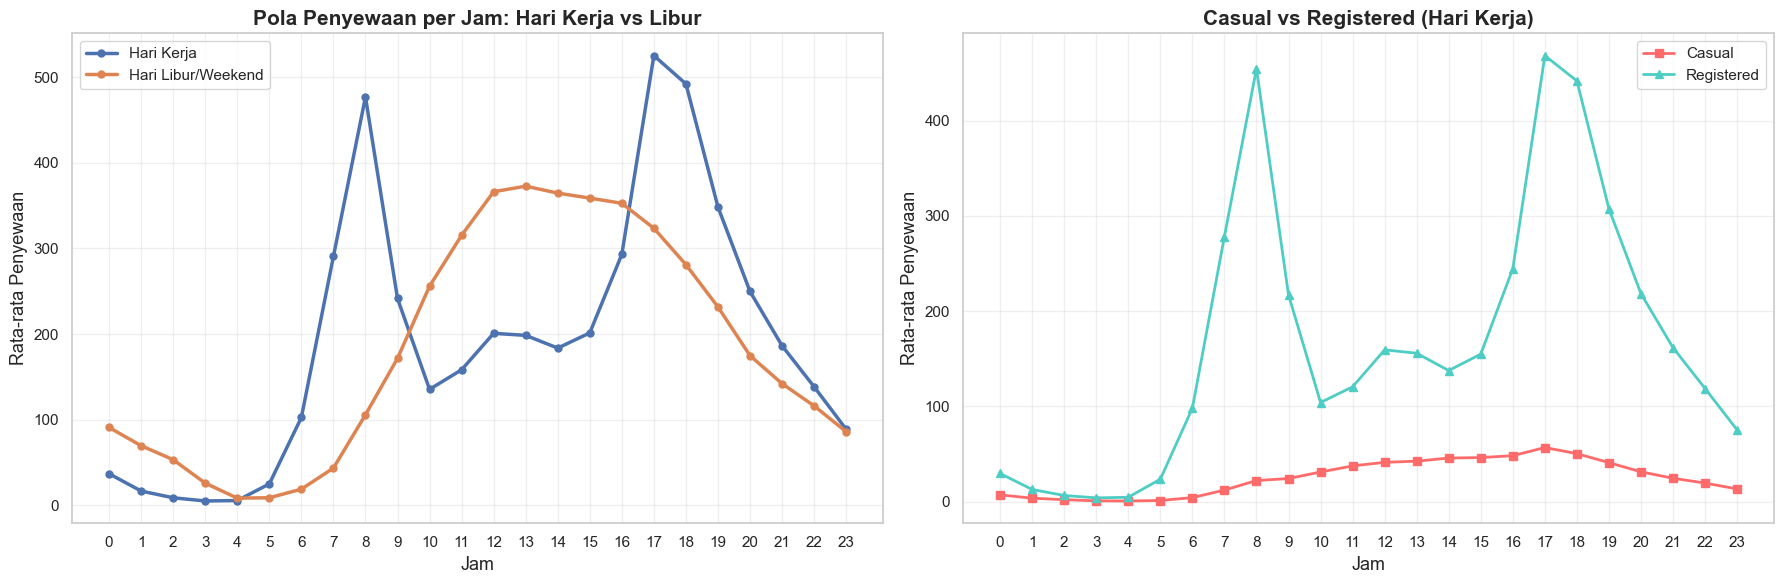

In [16]:
# Analisis pola per jam berdasarkan tipe hari
hourly_pattern = hour_df.groupby(['hr', 'day_type']).agg(
    avg_cnt=('cnt', 'mean'),
    avg_casual=('casual', 'mean'),
    avg_registered=('registered', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Total penyewaan per jam
for day_type in ['Hari Kerja', 'Hari Libur/Weekend']:
    data = hourly_pattern[hourly_pattern['day_type'] == day_type]
    axes[0].plot(data['hr'], data['avg_cnt'], marker='o', linewidth=2.5, markersize=5, label=day_type)

axes[0].set_xlabel('Jam', fontsize=13)
axes[0].set_ylabel('Rata-rata Penyewaan', fontsize=13)
axes[0].set_title('Pola Penyewaan per Jam: Hari Kerja vs Libur', fontsize=15, fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Casual vs Registered pada hari kerja
workday_data = hourly_pattern[hourly_pattern['day_type'] == 'Hari Kerja']
axes[1].plot(workday_data['hr'], workday_data['avg_casual'], marker='s', linewidth=2, label='Casual', color='#FF6B6B')
axes[1].plot(workday_data['hr'], workday_data['avg_registered'], marker='^', linewidth=2, label='Registered', color='#4ECDC4')
axes[1].set_xlabel('Jam', fontsize=13)
axes[1].set_ylabel('Rata-rata Penyewaan', fontsize=13)
axes[1].set_title('Casual vs Registered (Hari Kerja)', fontsize=15, fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

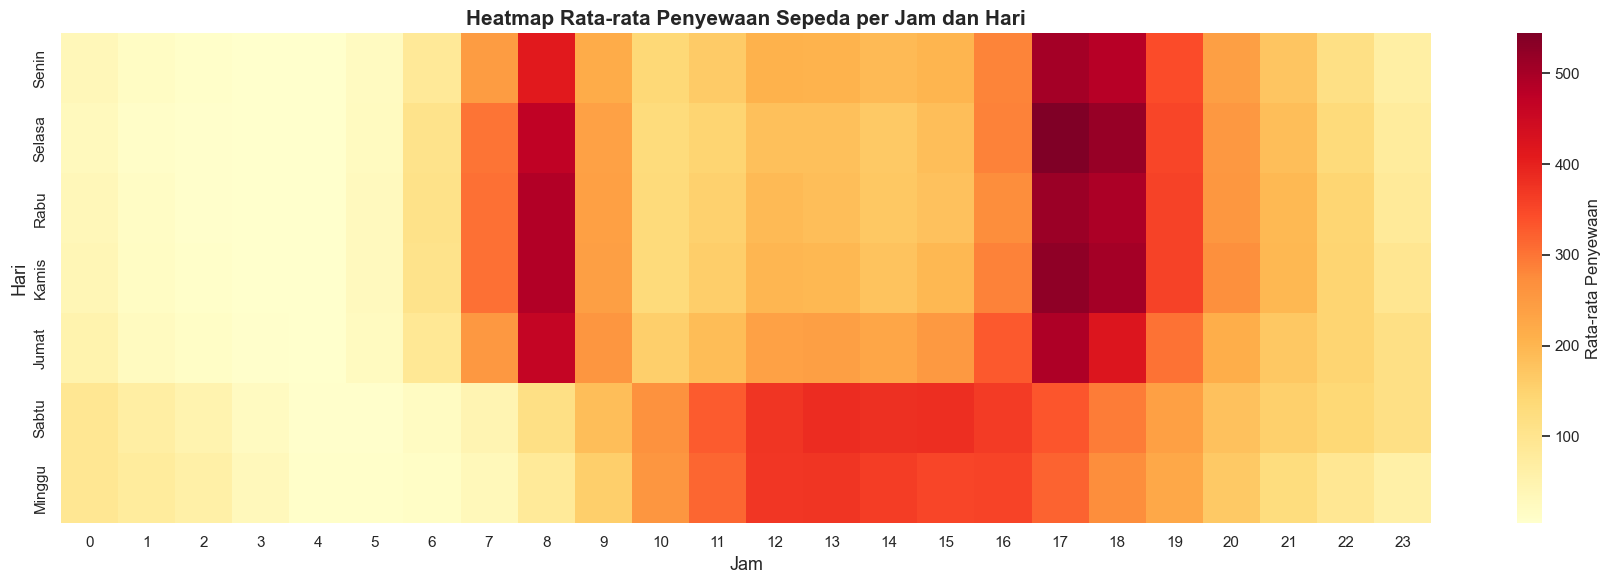


Puncak penyewaan Hari Kerja: Jam 17:00 (525 rata-rata penyewaan)

Puncak penyewaan Hari Libur/Weekend: Jam 13:00 (373 rata-rata penyewaan)


In [17]:
# Heatmap penyewaan per jam dan hari
weekday_order = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
heatmap_data = hour_df.pivot_table(values='cnt', index='weekday_label', columns='hr', aggfunc='mean')
heatmap_data = heatmap_data.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax,
            cbar_kws={'label': 'Rata-rata Penyewaan'})
ax.set_xlabel('Jam', fontsize=13)
ax.set_ylabel('Hari', fontsize=13)
ax.set_title('Heatmap Rata-rata Penyewaan Sepeda per Jam dan Hari', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifikasi puncak per tipe hari
for d_type in ['Hari Kerja', 'Hari Libur/Weekend']:
    data = hourly_pattern[hourly_pattern['day_type'] == d_type]
    peak_hour = data.loc[data['avg_cnt'].idxmax()]
    print(f"\nPuncak penyewaan {d_type}: Jam {int(peak_hour['hr']):02d}:00 ({peak_hour['avg_cnt']:.0f} rata-rata penyewaan)")

**Insight Pertanyaan 2:**
- **Hari kerja** menunjukkan pola bimodal (dua puncak) yang jelas:
  - Puncak pagi: sekitar jam 08:00 (jam berangkat kerja)
  - Puncak sore: sekitar jam 17:00-18:00 (jam pulang kerja)
- **Hari libur/weekend** menunjukkan pola unimodal (satu puncak):
  - Puncak terjadi sekitar jam 12:00-14:00 (tengah hari)
  - Distribusi lebih merata sepanjang hari
- Pada hari kerja, pengguna **registered** mendominasi dengan pola commuter yang jelas.
- Pengguna **casual** relatif stabil sepanjang hari dan meningkat saat siang hingga sore.
- Heatmap menunjukkan perbedaan yang sangat jelas antara pola Senin-Jumat (pola commuter) dan Sabtu-Minggu (pola rekreasi).

## Analisis Lanjutan: Clustering dengan Binning

Pada analisis lanjutan ini, kita akan melakukan **clustering menggunakan teknik binning** untuk mengelompokkan hari-hari berdasarkan tingkat aktivitas penyewaan sepeda. Pengelompokan ini berguna untuk memahami bagaimana faktor-faktor seperti cuaca, musim, dan temperatur mempengaruhi tingkat penyewaan.

In [18]:
# === Clustering dengan Binning berdasarkan jumlah penyewaan ===

# Menentukan batas-batas bin berdasarkan kuartil
q1 = day_df['cnt'].quantile(0.25)
q2 = day_df['cnt'].quantile(0.50)  # median
q3 = day_df['cnt'].quantile(0.75)

print(f"Q1 (25%): {q1:.0f}")
print(f"Q2 (50%/Median): {q2:.0f}")
print(f"Q3 (75%): {q3:.0f}")
print(f"Min: {day_df['cnt'].min()}, Max: {day_df['cnt'].max()}")

# Membuat kategori/cluster berdasarkan binning
bins = [0, q1, q2, q3, day_df['cnt'].max() + 1]
labels_cluster = ['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']

day_df['usage_cluster'] = pd.cut(day_df['cnt'], bins=bins, labels=labels_cluster, include_lowest=True)

print(f"\nDistribusi Cluster:")
print(day_df['usage_cluster'].value_counts().sort_index())

Q1 (25%): 3152
Q2 (50%/Median): 4548
Q3 (75%): 5956
Min: 22, Max: 8714

Distribusi Cluster:
usage_cluster
Rendah           183
Sedang           183
Tinggi           182
Sangat Tinggi    183
Name: count, dtype: int64


In [19]:
# Visualisasi karakteristik setiap cluster
cluster_order = ['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']

cluster_stats = day_df.groupby('usage_cluster', observed=True).agg(
    jumlah_hari=('cnt', 'count'),
    avg_cnt=('cnt', 'mean'),
    avg_temp=('temp_actual', 'mean'),
    avg_hum=('hum', 'mean'),
    avg_windspeed=('windspeed', 'mean'),
    avg_casual=('casual', 'mean'),
    avg_registered=('registered', 'mean')
).reindex(cluster_order)

print("Karakteristik setiap cluster:")
print(cluster_stats.round(2).to_string())

Karakteristik setiap cluster:
               jumlah_hari  avg_cnt  avg_temp  avg_hum  avg_windspeed  avg_casual  avg_registered
usage_cluster                                                                                    
Rendah                 183  1933.58      6.52     0.64           0.22      278.77         1654.81
Sedang                 183  3916.65     14.96     0.65           0.19      642.79         3273.86
Tinggi                 182  5128.13     18.51     0.62           0.18      973.09         4155.03
Sangat Tinggi          183  7042.45     21.17     0.61           0.17     1498.73         5543.72


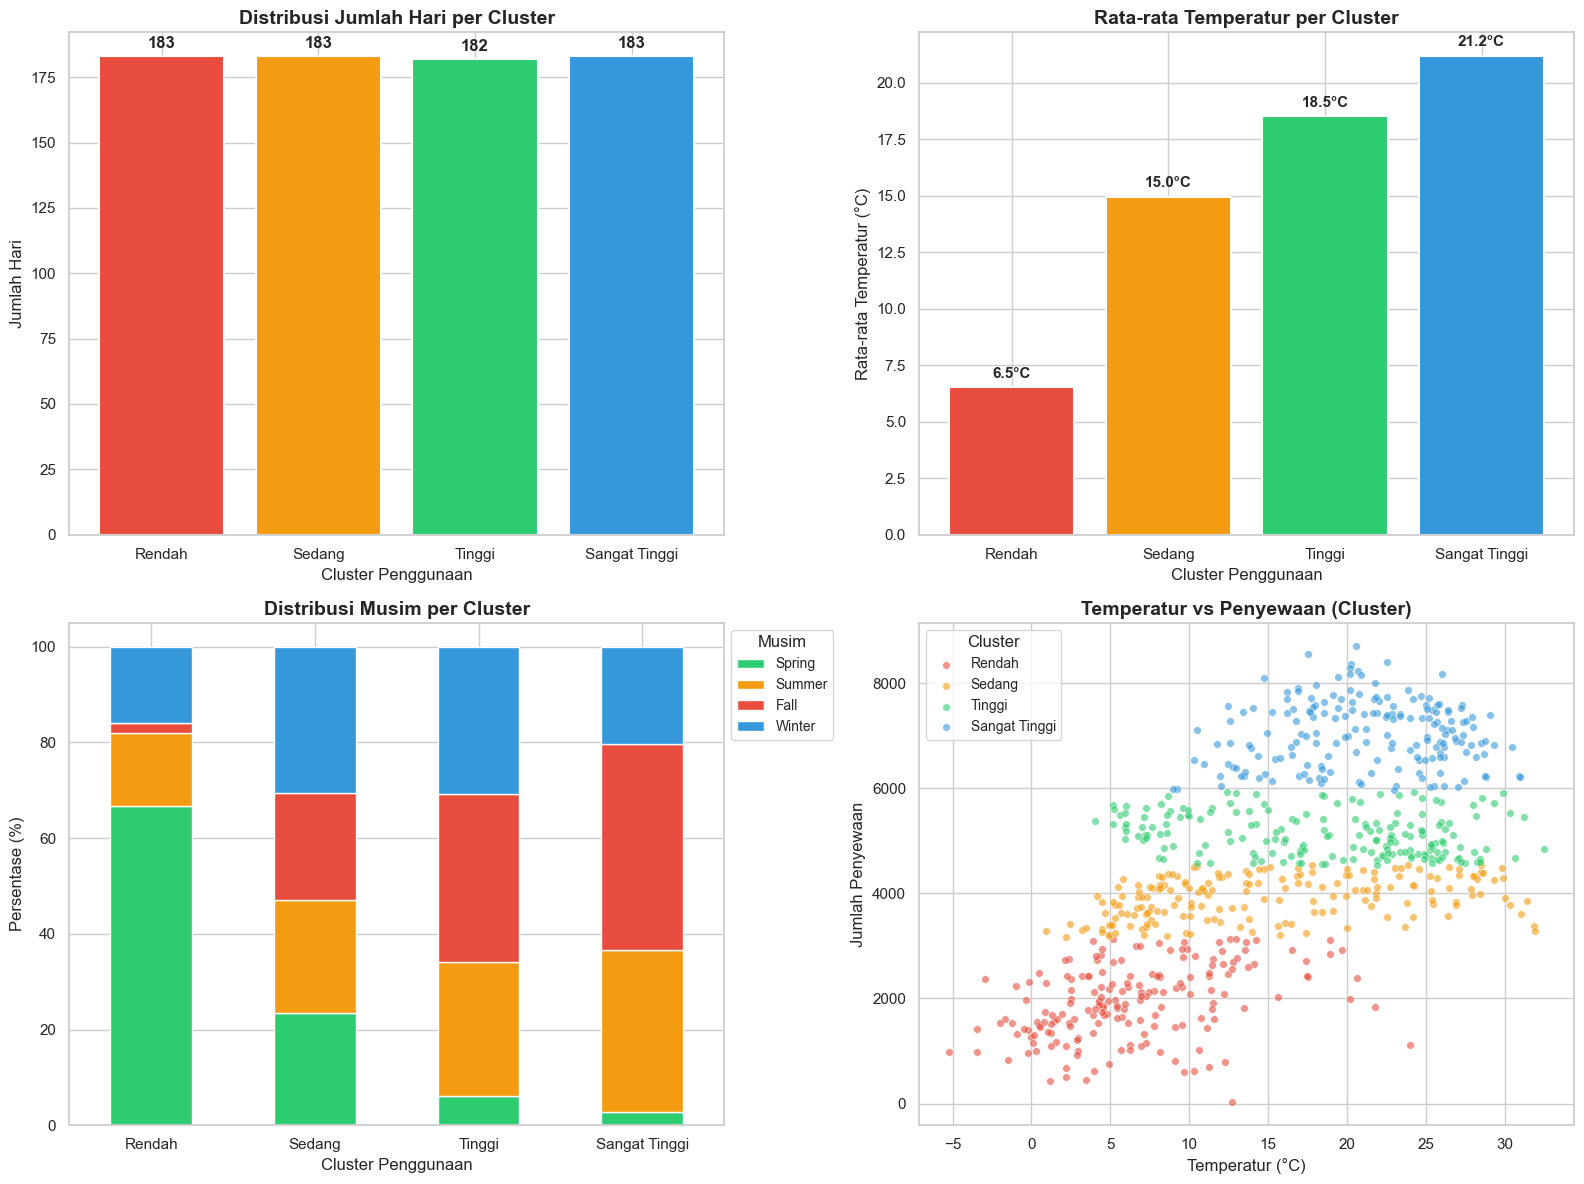

In [20]:
# Visualisasi cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors_cluster = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']

# 1. Distribusi jumlah hari per cluster
cluster_counts = day_df['usage_cluster'].value_counts().reindex(cluster_order)
bars = axes[0, 0].bar(cluster_order, cluster_counts, color=colors_cluster, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cluster_counts):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                    f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Cluster Penggunaan', fontsize=12)
axes[0, 0].set_ylabel('Jumlah Hari', fontsize=12)
axes[0, 0].set_title('Distribusi Jumlah Hari per Cluster', fontsize=14, fontweight='bold')

# 2. Rata-rata temperatur per cluster
bars = axes[0, 1].bar(cluster_order, cluster_stats['avg_temp'], color=colors_cluster, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cluster_stats['avg_temp']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                    f'{val:.1f}°C', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0, 1].set_xlabel('Cluster Penggunaan', fontsize=12)
axes[0, 1].set_ylabel('Rata-rata Temperatur (°C)', fontsize=12)
axes[0, 1].set_title('Rata-rata Temperatur per Cluster', fontsize=14, fontweight='bold')

# 3. Distribusi musim per cluster
season_cluster = pd.crosstab(day_df['usage_cluster'], day_df['season_label'], normalize='index') * 100
season_cluster = season_cluster.reindex(cluster_order)
season_cluster = season_cluster[['Spring', 'Summer', 'Fall', 'Winter']]
season_cluster.plot(kind='bar', stacked=True, ax=axes[1, 0],
                    color=['#2ECC71', '#F39C12', '#E74C3C', '#3498DB'])
axes[1, 0].set_xlabel('Cluster Penggunaan', fontsize=12)
axes[1, 0].set_ylabel('Persentase (%)', fontsize=12)
axes[1, 0].set_title('Distribusi Musim per Cluster', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Musim', fontsize=10, bbox_to_anchor=(1.0, 1.0))
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Scatter plot: temperatur vs penyewaan dengan cluster
for i, cluster in enumerate(cluster_order):
    data = day_df[day_df['usage_cluster'] == cluster]
    axes[1, 1].scatter(data['temp_actual'], data['cnt'], c=colors_cluster[i],
                       label=cluster, alpha=0.6, s=30, edgecolors='white', linewidth=0.5)
axes[1, 1].set_xlabel('Temperatur (°C)', fontsize=12)
axes[1, 1].set_ylabel('Jumlah Penyewaan', fontsize=12)
axes[1, 1].set_title('Temperatur vs Penyewaan (Cluster)', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Cluster', fontsize=10)

plt.tight_layout()
plt.show()

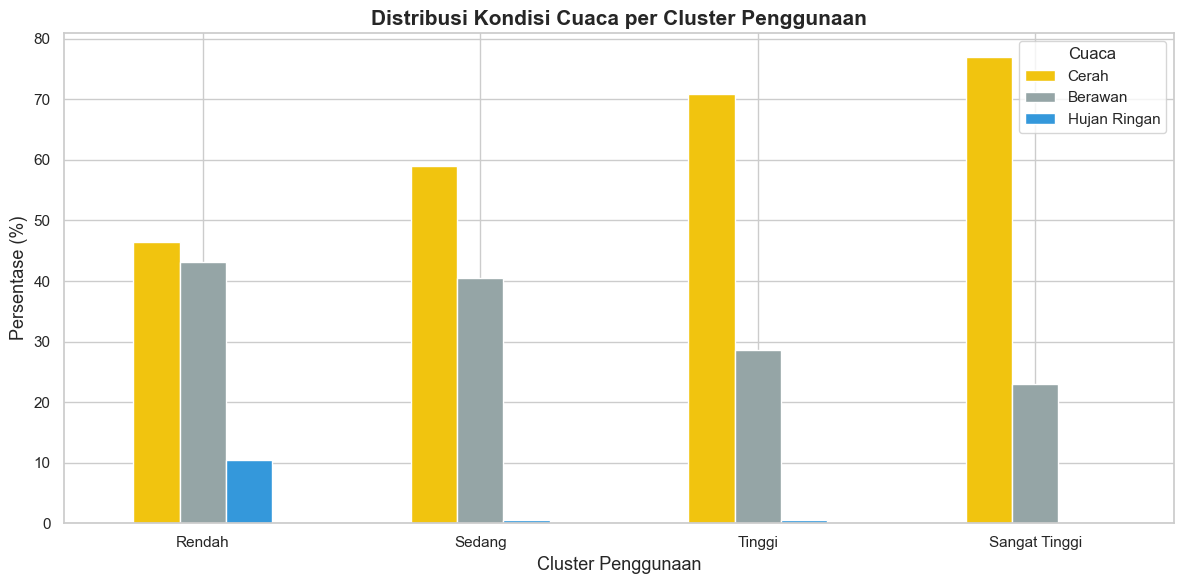


Persentase Cuaca per Cluster:
weather_label  Berawan  Cerah  Hujan Ringan
usage_cluster                              
Rendah            43.2   46.4          10.4
Sedang            40.4   59.0           0.5
Tinggi            28.6   70.9           0.5
Sangat Tinggi     23.0   77.0           0.0


In [21]:
# Distribusi kondisi cuaca per cluster
weather_cluster = pd.crosstab(day_df['usage_cluster'], day_df['weather_label'], normalize='index') * 100
weather_cluster = weather_cluster.reindex(cluster_order)

fig, ax = plt.subplots(figsize=(12, 6))
weather_cols_available = [c for c in ['Cerah', 'Berawan', 'Hujan Ringan', 'Hujan Lebat'] if c in weather_cluster.columns]
weather_cluster[weather_cols_available].plot(kind='bar', ax=ax,
                                             color=['#F1C40F', '#95A5A6', '#3498DB', '#2C3E50'][:len(weather_cols_available)])
ax.set_xlabel('Cluster Penggunaan', fontsize=13)
ax.set_ylabel('Persentase (%)', fontsize=13)
ax.set_title('Distribusi Kondisi Cuaca per Cluster Penggunaan', fontsize=15, fontweight='bold')
ax.legend(title='Cuaca', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print("\nPersentase Cuaca per Cluster:")
print(weather_cluster.round(1).to_string())

**Insight Analisis Lanjutan (Clustering):**
- Hari-hari berhasil dikelompokkan menjadi 4 cluster berdasarkan tingkat penyewaan: **Rendah, Sedang, Tinggi, dan Sangat Tinggi**.
- **Cluster Rendah**: Didominasi hari-hari di musim Spring dengan temperatur rata-rata rendah (~10°C) dan proporsi cuaca hujan tertinggi.
- **Cluster Sangat Tinggi**: Terjadi pada hari-hari dengan temperatur tinggi (~24°C), didominasi musim Summer dan Fall dengan cuaca cerah.
- **Temperatur menjadi faktor pembeda utama** antar cluster — semakin tinggi temperatur, semakin tinggi penyewaan.
- Dari scatter plot, terlihat korelasi positif yang kuat antara temperatur dan jumlah penyewaan, namun pada temperatur sangat tinggi (>35°C) terjadi penurunan (diminishing returns).

## Conclusion

### Kesimpulan Pertanyaan 1: Pola Penggunaan Berdasarkan Musim dan Cuaca

- **Musim Fall (Gugur) menjadi musim paling populer** untuk penyewaan sepeda dengan rata-rata penyewaan harian tertinggi, diikuti oleh Summer (Panas), Winter (Dingin), dan Spring (Semi) yang memiliki penyewaan terendah.
- **Cuaca cerah meningkatkan penyewaan secara signifikan**, dengan rata-rata penyewaan 2-3x lipat dibandingkan kondisi hujan ringan.
- Pengguna **registered** mendominasi di semua musim dan cuaca, tetapi proporsi pengguna **casual** meningkat pada musim panas dan cuaca cerah, menunjukkan pola rekreasi musiman.
- Implikasi bisnis: Promosi dan ketersediaan sepeda perlu ditingkatkan saat musim Fall dan Summer, serta pada hari-hari dengan prakiraan cuaca cerah.

### Kesimpulan Pertanyaan 2: Pola Hari Kerja vs Hari Libur

- **Hari kerja** menunjukkan **pola bimodal** dengan dua puncak jelas: jam 08:00 (commute pagi) dan jam 17:00-18:00 (commute sore). Ini mengindikasikan penggunaan sebagai alat transportasi utama.
- **Hari libur/weekend** menunjukkan **pola unimodal** dengan puncak di sekitar jam 12:00-14:00, menunjukkan penggunaan bersifat rekreasi.
- Pengguna **registered** mendominasi pola commuter di hari kerja, sementara pengguna **casual** menyebar lebih merata dan meningkat di hari libur.
- Implikasi bisnis: Kapasitas sepeda perlu dimaksimalkan pada rush hour (07:00-09:00 dan 16:00-19:00) di hari kerja, sementara pada weekend sebaiknya fokus pada area rekreasi.

### Kesimpulan Analisis Lanjutan (Clustering)

- Dengan teknik **binning berbasis kuartil**, hari-hari berhasil dikelompokkan menjadi 4 cluster berdasarkan volume penyewaan.
- **Temperatur terbukti menjadi faktor pembeda utama** antara cluster — hari dengan penyewaan tinggi cenderung memiliki temperatur lebih hangat.
- **Musim dan cuaca juga berperan signifikan**: Cluster rendah didominasi Spring dan cuaca buruk, sementara cluster tinggi didominasi Summer/Fall dan cuaca cerah.
- Pengelompokan ini dapat digunakan untuk **perencanaan operasional**: menyesuaikan jumlah sepeda tersedia, jadwal maintenance, dan strategi harga berdasarkan prediksi cluster dari faktor cuaca dan musim.